# Lab Report #6: Neural Networks
RSM338<br>
Prof. K. Mott<br>
Submitted by Dong-Hyun Michael Kim<br>
2026-04-08
## Part A: Classification
### 1. Data Preparation

In [1]:
import pandas as pd

# Load the Excel file into a dataframe
raw_df = pd.read_excel('lending_clubFull_Data_Set.xlsx')

### Features we will include for prediction
| Feature | Description |
| --- | --- |
| ```emp_length``` | employment length in years |
| ```home_ownership``` | whether borrower rents, owns, has mortgage, etc. |
| ```dti``` | monthly debt to monthly income |
| ```delinq_2yrs``` | number of 30+ dpd (days past due) delinquencies in the past 2 years |
| ```earliest_cr_line``` | month of the borrower's earliest reported credit line |
| ```inq_last_6mths``` | no. of inquiries in the past 6 months (except auto or mortgage) |
| ```revol_util``` | amt. of credit borrower is using relative to all available revolving credit |
| ```acc_now_delinq``` | current no. of delinquent accounts |
| ```bc_util``` | ratio of total current balance to high credit/credit limit for all bankcard accounts |
| ```num_tl_120dpd_2m``` | no. of accounts currently 120 dpd (updated in past 2 months) |
| ```num_tl_30dpd``` | no. of accounts currently 30 dpd (updated in past 2 months) |
| ```num_tl_90g_dpd_24m``` | no. of accounts 90+ dpd in last 24 months |

Target variable: ```loan_status```<br>
Possible values: Charged Off, Current, Fully Paid, Late, In Grace Period, Default

We convert this column to binary data, where the value is 1 if in default or charged off, and 0 otherwise.

In [5]:
# Keep only the selected features, plus the target variable
df = raw_df[[
    'loan_status',
    'emp_length',
    'home_ownership',
    'dti',
    'delinq_2yrs',
    'earliest_cr_line',
    'inq_last_6mths',
    'revol_util',
    'acc_now_delinq',
    'bc_util',
    'num_tl_120dpd_2m',
    'num_tl_30dpd',
    'num_tl_90g_dpd_24m'
]]

# Remove loans that do not meet the credit policy
df = df[~df['loan_status'].str.contains('Does not meet the credit policy. Status:', na=False)]

# convert loan_status column to binary values - 1 if default, charged off, or 30+ days late, otherwise 0
df['loan_status'] = df['loan_status'].apply(lambda x: 1 if x in ['Default', 'Charged Off', 'Late (31-120 days)'] else 0)

Now we clean the data for the other features.

In [6]:
# reduce home_ownership column to OWN, MORTGAGE, RENT
for keyword in ['ANY', 'OTHER', 'NONE']:
    df = df[~df['home_ownership'].str.contains(keyword, na=False)]

# convert home_ownership column to numbers
df['home_ownership'] = df['home_ownership'].replace('OWN', 1)
df['home_ownership'] = df['home_ownership'].replace('MORTGAGE', 0)
df['home_ownership'] = df['home_ownership'].replace('RENT', -1)

# convert emp_length column to numbers
df['emp_length'] = df['emp_length'].fillna(0)
df['emp_length'] = df['emp_length'].replace('< 1 year', 0.5)
df['emp_length'] = df['emp_length'].replace('1 year', 1)
for i in range(2, 10):
    find = str(i) + ' years'
    df['emp_length'] = df['emp_length'].replace(find, i)
df['emp_length'] = df['emp_length'].replace('10+ years', 10)
df['emp_length'] = pd.to_numeric(df['emp_length'], errors='coerce')

# remove rows which have empty cells in certain columns
for col in ['home_ownership', 'dti', 'revol_util', 'bc_util']:
    df = df.dropna(subset=[col])

df['num_tl_120dpd_2m'] = df['num_tl_120dpd_2m'].fillna(0)
df['num_tl_30dpd'] = df['num_tl_30dpd'].fillna(0)#
df['num_tl_90g_dpd_24m'] = df['num_tl_90g_dpd_24m'].fillna(0)

# convert earliest cr_line to numerical data
epoch = pd.Timestamp('1970-01-01')
df['earliest_cr_line'] = (df['earliest_cr_line'].dt.year - epoch.year) * 12 + (df['earliest_cr_line'].dt.month - epoch.month)

We will split the data into training (60%), validation (20%), and test (20%) sets, and standardize the training set features. Then we will convert the sets to PyTorch tensors.

We require a third set split (the validation set) in order to determine the optimal weights out of the series generated by training the neural network.

In [7]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_80, X_test, y_80, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_80, y_80, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

print(f"Training set:   {X_train_t.shape[0]} observations")
print(f"Validation set: {X_val_t.shape[0]} observations")
print(f"Test set:       {X_test_t.shape[0]} observations")

Training set:   14380 observations
Validation set: 4794 observations
Test set:       4794 observations


### 2. Building and Training a Neural Network

In [8]:
from torch.utils.data import TensorDataset, DataLoader

def train_nn(neurons = 64, loss_fn = nn.BCELoss(), rate=0.001, b_size = 64):
    # Build a feed-forward neural network
    model = nn.Sequential(
        nn.Linear(12, neurons),        # hidden layer 1
        nn.ReLU(),
        nn.Linear(neurons, neurons),   # hidden layer 2
        nn.ReLU(),
        nn.Linear(neurons, 1),         # output layer: 1 neuron
        nn.Sigmoid()          # sigmoid for binary classification
    )

    # Initialize optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=rate)

    print(model)
    print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Create data loader for mini-batching
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=b_size, shuffle=True)

    # Training loop
    train_losses = []
    val_losses = []

    torch.manual_seed(42)

    for epoch in range(500):
        # Training phase
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()           # reset gradients
            y_pred = model(X_batch)         # forward pass
            loss = loss_fn(y_pred, y_batch) # compute loss
            loss.backward()                 # backpropagation
            optimizer.step()                # update weights

        # Record losses (no gradients needed for evaluation)
        with torch.no_grad():
            train_losses.append(loss_fn(model(X_train_t), y_train_t).item())
            val_losses.append(loss_fn(model(X_val_t), y_val_t).item())

    print(f"Final training loss: {train_losses[-1]:.4f}")
    print(f"Final validation loss: {val_losses[-1]:.4f}")
    return (train_losses, val_losses, model)

train_losses, val_losses, model = train_nn()

Sequential(
  (0): Linear(in_features=12, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=1, bias=True)
  (5): Sigmoid()
)

Total parameters: 5,057
Final training loss: 0.1951
Final validation loss: 0.6724


As we can see there are roughly three times more observations than features, and hopefully this means the high dimensionality does not introduce a significant amount of error to our predictions. We will proceed by plotting training and validation loss against epochs during training.

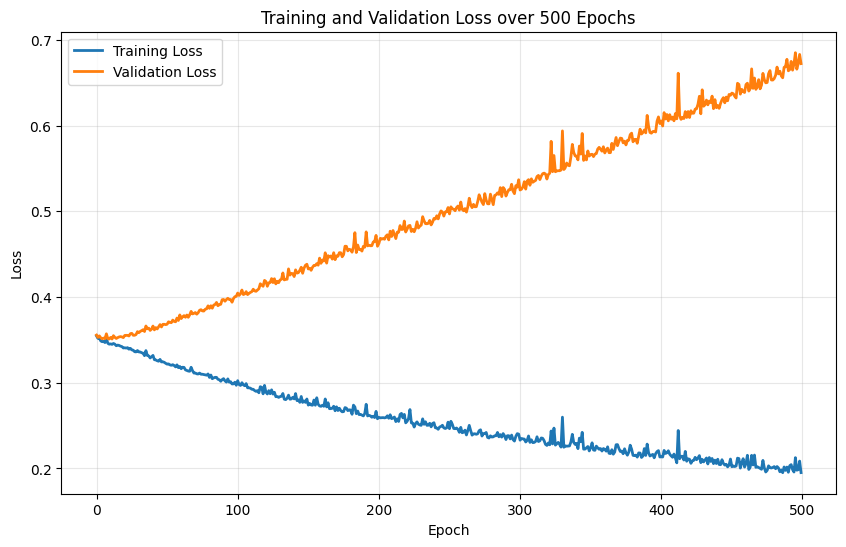

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over 500 Epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Under this model, the validation loss seems to increase almost immediately, which is most likely attributable to overfitting - the model memorizes the noise in the training data (evident in the decreasing curve of training loss) which does not help at all for data it has yet to see. Some more statistics of the model are outputted by the code below.

In [10]:
from sklearn.metrics import recall_score, roc_auc_score, confusion_matrix

# Evaluate on the held-out test set
def eval(eval_model = model):
    with torch.no_grad():
        test_pred = eval_model(X_test_t)
        test_accuracy = ((test_pred > 0.5) == y_test_t).float().mean().item()

    print(f"Test accuracy: {test_accuracy:.3f}")

    # Get predictions and probabilities
    test_pred_proba = eval_model(X_test_t).detach().numpy()  # probabilities (0-1)
    test_pred_binary = (test_pred_proba > 0.5).astype(int)  # binary predictions
    y_test_true = y_test_t.numpy()

    # Calculate metrics
    recall = recall_score(y_test_true, test_pred_binary)
    auc = roc_auc_score(y_test_true, test_pred_proba)

    # Confusion matrix
    cm = confusion_matrix(y_test_true, test_pred_binary)

    print(f"Test Recall:   {recall:.4f}")
    print(f"Test AUC:      {auc:.4f}")
    print(f"\nConfusion Matrix:")
    print(cm)
    return (test_accuracy, recall, auc)

accuracy, recall, auc = eval()

Test accuracy: 0.841
Test Recall:   0.0887
Test AUC:      0.5248

Confusion Matrix:
[[3987  277]
 [ 483   47]]


### 3. Experimentation
Here we attempt to change some hyperparameters on the neural network to improve generalization performance.

**Model 1**: increase neurons from 64 per layer to 128<br>
Because we were curious to see if investing more time would improve generalization.

In [11]:
train_losses_1, val_losses_1, model_1 = train_nn(128)

Sequential(
  (0): Linear(in_features=12, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=1, bias=True)
  (5): Sigmoid()
)

Total parameters: 18,305
Final training loss: 0.0778
Final validation loss: 1.5337


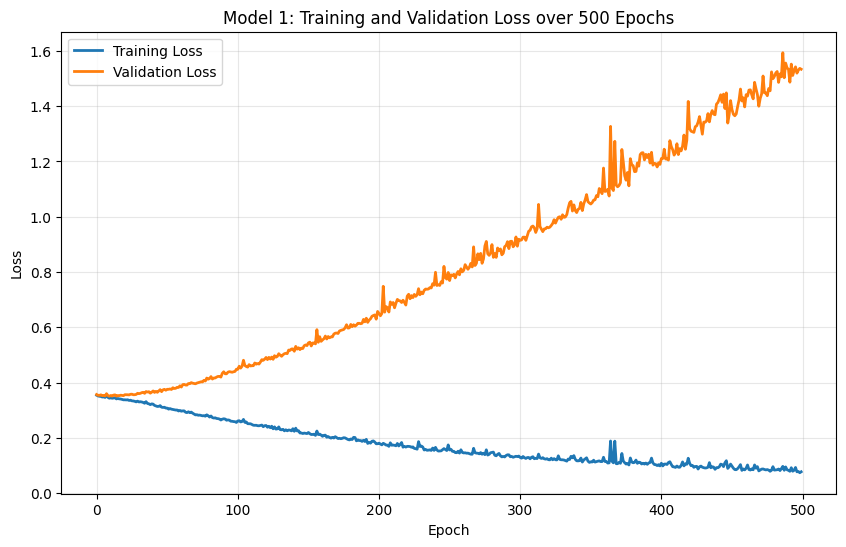

Test accuracy: 0.822
Test Recall:   0.0962
Test AUC:      0.5111

Confusion Matrix:
[[3891  373]
 [ 479   51]]


In [12]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses_1, label='Training Loss', linewidth=2)
plt.plot(val_losses_1, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model 1: Training and Validation Loss over 500 Epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

accuracy, recall, auc = eval(model_1)

Here it seems overall performance actually worsens, which in retrospect makes sense since our issue was overfitting.

**Model 2**: 32 neurons instead of 64

In [13]:
train_losses_2, val_losses_2, model_2 = train_nn(32)

Sequential(
  (0): Linear(in_features=12, out_features=32, bias=True)
  (1): ReLU()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
  (5): Sigmoid()
)

Total parameters: 1,505
Final training loss: 0.2901
Final validation loss: 0.4253


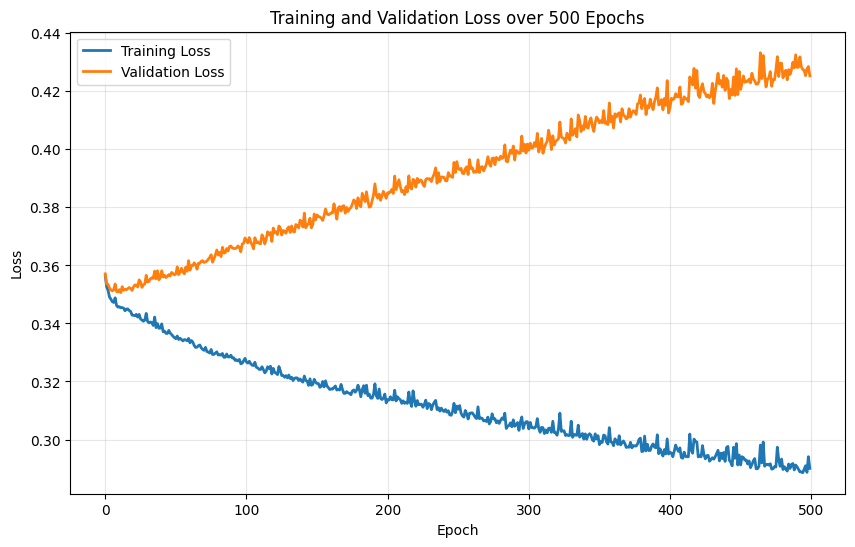

Test accuracy: 0.873
Test Recall:   0.0396
Test AUC:      0.5618

Confusion Matrix:
[[4162  102]
 [ 509   21]]


In [14]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses_2, label='Training Loss', linewidth=2)
plt.plot(val_losses_2, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over 500 Epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

accuracy, recall, auc = eval(model_2)

As expected performance improves even if slightly.

**Model 3**: 16 neurons, batch size 128 instead of 64

In [15]:
train_losses_3, val_losses_3, model_3 = train_nn(16, b_size=128)

Sequential(
  (0): Linear(in_features=12, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
  (5): Sigmoid()
)

Total parameters: 497
Final training loss: 0.3369
Final validation loss: 0.3636


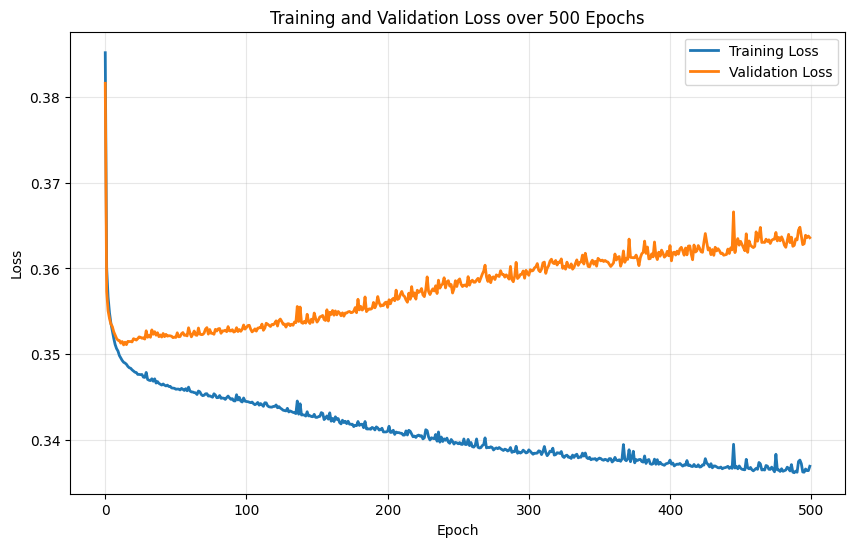

Test accuracy: 0.887
Test Recall:   0.0019
Test AUC:      0.5892

Confusion Matrix:
[[4249   15]
 [ 529    1]]


In [16]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses_3, label='Training Loss', linewidth=2)
plt.plot(val_losses_3, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over 500 Epochs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

accuracy, recall, auc = eval(model_3)

Notably accuracy increases but recall decreases sharply. Validation loss, however, seems to decrease sharply in the beginning as well.

### 4. Comparison to Lab Report 5
Here we compare our best neural network to some models from the previous report - namely, Logistic Regression, Random Forest, and XGBoost.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


LR_THRESHOLD = 0.15

# Fit logistic regression
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# Get predictions on test set
y_pred = log_reg.predict(X_test_scaled)

# Predict probabilities and apply threshold
prob_pred = log_reg.predict_proba(X_test_scaled)[:, 1]
class_pred = (prob_pred > LR_THRESHOLD).astype(int)

# Evaluate Logistic Regression
lr_accuracy = accuracy_score(y_test, class_pred)
lr_recall = recall_score(y_test, class_pred)
lr_auc = roc_auc_score(y_test, prob_pred)

# Train a Random Forest
rf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_features='sqrt',   # features per split = sqrt(p)
    oob_score=True,        # compute out-of-bag accuracy
    class_weight='balanced',
    random_state=42
)
rf.fit(X_train_scaled, y_train)

# Evaluate Random Forest
rf_pred = rf.predict(X_test_scaled)
rf_pred_proba = rf.predict_proba(X_test_scaled)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_pred_proba)

# Train XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    reg_lambda=1.0,        # L2 regularization
    scale_pos_weight=9,
    random_state=42
)
xgb.fit(X_train_scaled, y_train)

# Evaluate XGBoost
xgb_pred = xgb.predict(X_test_scaled)
xgb_pred_proba = xgb.predict_proba(X_test_scaled)[:, 1]

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)

In [18]:
# Create a summary table of all model metrics
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Neural Network'],
    'Accuracy': [lr_accuracy, rf_accuracy, xgb_accuracy, accuracy],
    'Recall': [lr_recall, rf_recall, xgb_recall, recall,],
    'AUC': [lr_auc, rf_auc, xgb_auc, auc]
})

print("\nModel Comparison Summary:")
print(results.to_string(index=False))
print("\n" + "="*60)
print(f"Best Accuracy:  {results.loc[results['Accuracy'].idxmax(), 'Model']}")
print(f"Best Recall:    {results.loc[results['Recall'].idxmax(), 'Model']}")
print(f"Best AUC:       {results.loc[results['AUC'].idxmax(), 'Model']}")



Model Comparison Summary:
              Model  Accuracy   Recall      AUC
Logistic Regression  0.784940 0.252830 0.596887
      Random Forest  0.889028 0.001887 0.594938
            XGBoost  0.551731 0.616981 0.610168
     Neural Network  0.886525 0.001887 0.589202

Best Accuracy:  Random Forest
Best Recall:    XGBoost
Best AUC:       XGBoost


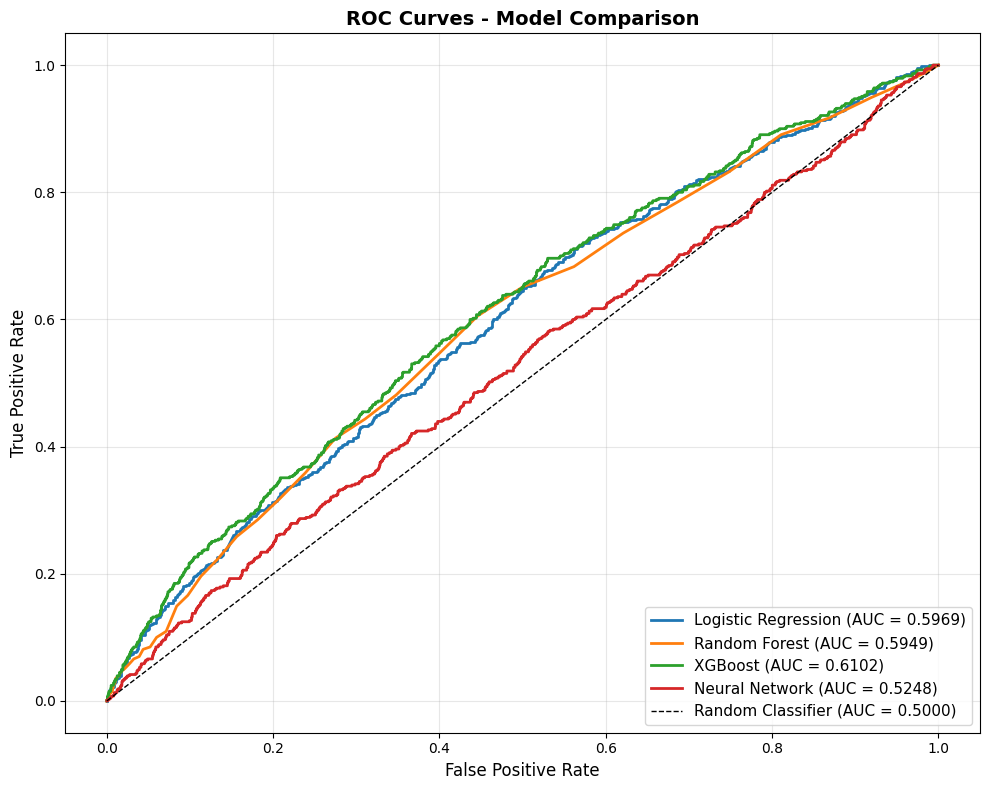

In [19]:
from sklearn.metrics import roc_curve, auc

# Get neural network predictions
nn_pred_proba = model(X_test_t).detach().numpy().flatten()

# Calculate ROC curves for all models
lr_fpr, lr_tpr, _ = roc_curve(y_test, prob_pred)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_pred_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_pred_proba)
nn_fpr, nn_tpr, _ = roc_curve(y_test_t.numpy(), nn_pred_proba)

# Calculate AUC values
lr_auc_roc = auc(lr_fpr, lr_tpr)
rf_auc_roc = auc(rf_fpr, rf_tpr)
xgb_auc_roc = auc(xgb_fpr, xgb_tpr)
nn_auc_roc = auc(nn_fpr, nn_tpr)

# Plot ROC curves
plt.figure(figsize=(10, 8))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc_roc:.4f})', linewidth=2)
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc_roc:.4f})', linewidth=2)
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc_roc:.4f})', linewidth=2)
plt.plot(nn_fpr, nn_tpr, label=f'Neural Network (AUC = {nn_auc_roc:.4f})', linewidth=2)

# Add diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5000)', linewidth=1)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In this case the neural network seems to match the other models in terms of accuracy and recall, although it underperforms when comparing the ROC curves. We believe this is because a neural network can be thought of as a generalization of a regression, so it is more likely to outperform other models when it is approximating a nonlinear function.
## Part B: Regression
### 5: Training on Black-Scholes samples
Here we get a neural network to learn and predict output values of the Black-Scholes formula based on its inputs. First we generate 50000 sets of sample inputs as well as their true formula output values. (We were supposed to generate 100000 but due to hardware constraints decided to generate 50000 instead)

In [20]:
import math
import scipy

def black_scholes(s, k, t, r, sigma):
    d1 = (math.log(s / k) + t * (r + (sigma**2)/2)) / (sigma * math.sqrt(t))
    d2 = d1 - sigma * math.sqrt(t)
    temp1 = s * scipy.stats.norm.cdf(d1)
    temp2 = k * scipy.stats.norm.cdf(d2) * math.e**(-r * t)
    return temp1 - temp2

np.random.seed(42)

def sample_black_scholes(n = 100000):
    s = np.random.uniform(low=40, high=60, size=n)
    t = np.random.uniform(low=0.25, high=2, size=n)
    r = np.random.uniform(high=0.05, size=n)
    sigma = np.random.uniform(low=0.1, high=0.4, size=n)
    k = []
    price = []
    for i in range(n):
        val = np.random.uniform(low=0.5*s[i], high=1.5*s[i])
        k.append(val)
        price.append(black_scholes(s[i], val, t[i], r[i], sigma[i]))
    
    return pd.DataFrame({
        'S_0': s,
        'K': k,
        'T': t,
        'r': r,
        'sigma': sigma,
        'price': price
    })

options_df = sample_black_scholes(50000)

Again, we split the data 60/20/20 as training, validation, and test sets.

In [21]:
options_X = options_df.drop('price', axis=1)
options_y = options_df['price']

options_X_80, options_X_test, options_y_80, options_y_test = train_test_split(
    options_X, options_y, test_size=0.2, random_state=42
)

options_X_train, options_X_val, options_y_train, options_y_val = train_test_split(
    options_X_80, options_y_80, test_size=0.25, random_state=42
)

scaler = StandardScaler()
options_X_train_scaled = scaler.fit_transform(options_X_train)
options_X_val_scaled = scaler.transform(options_X_val)
options_X_test_scaled = scaler.transform(options_X_test)

# Convert to PyTorch tensors
options_X_train_t = torch.tensor(options_X_train_scaled, dtype=torch.float32)
options_y_train_t = torch.tensor(options_y_train.values, dtype=torch.float32).unsqueeze(1)
options_X_val_t = torch.tensor(options_X_val_scaled, dtype=torch.float32)
options_y_val_t = torch.tensor(options_y_val.values, dtype=torch.float32).unsqueeze(1)
options_X_test_t = torch.tensor(options_X_test_scaled, dtype=torch.float32)
options_y_test_t = torch.tensor(options_y_test.values, dtype=torch.float32).unsqueeze(1)

As a benchmark, we will run a standard linear regression on the data.

In [22]:
from sklearn.linear_model import LinearRegression

# Fit on training data only
base_model = LinearRegression()
base_model.fit(options_X_train, options_y_train)

# Evaluate on test data
test_mse = np.mean((options_y_test - base_model.predict(options_X_test))**2)

print(f"Test MSE: {test_mse:.4f}")

def oos_r_squared(y_actual, y_predicted, y_mean_benchmark):
    """
    Compute out-of-sample R-squared.

    y_actual: actual returns
    y_predicted: model predictions
    y_mean_benchmark: historical mean predictions
    """
    ss_model = np.sum((y_actual - y_predicted)**2)
    ss_benchmark = np.sum((y_actual - y_mean_benchmark)**2)
    return 1 - ss_model / ss_benchmark

y_pred = base_model.predict(options_X_test)
y_benchmark = np.full(len(options_y_test), options_y_train.mean())

oos_r2 = oos_r_squared(options_y_test, y_pred, y_benchmark)
print(f"OOS R²: {oos_r2:.4f}")

Test MSE: 6.2188
OOS R²: 0.8972


And now, we train a neural network to predict prices.

In [23]:
loss_fn = nn.MSELoss()
neurons = 32
b_size = 32
rate = 0.001

# Build a feed-forward neural network
options_nn_model = nn.Sequential(
    nn.Linear(5, neurons),        # hidden layer 1
    nn.Tanh(),
    nn.Linear(neurons, neurons),   # hidden layer 2
    nn.Tanh(),
    nn.Linear(neurons, 1),         # output layer: 1 neuron
    nn.Softplus()
)

# Initialize optimizer
optimizer = torch.optim.Adam(options_nn_model.parameters(), lr=rate)

print(options_nn_model)
print(f"\nTotal parameters: {sum(p.numel() for p in options_nn_model.parameters()):,}")

# Create data loader for mini-batching
train_loader = DataLoader(TensorDataset(options_X_train_t, options_y_train_t), batch_size=b_size, shuffle=True)

# Training loop
options_train_losses = []
options_val_losses = []

torch.manual_seed(42)

for epoch in range(100):
    # Training phase
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()           # reset gradients
        y_pred = options_nn_model(X_batch)         # forward pass
        loss = loss_fn(y_pred, y_batch) # compute loss
        loss.backward()                 # backpropagation
        optimizer.step()                # update weights

        # Record losses (no gradients needed for evaluation)
    with torch.no_grad():
        options_train_losses.append(loss_fn(options_nn_model(options_X_train_t), options_y_train_t).item())
        options_val_losses.append(loss_fn(options_nn_model(options_X_val_t), options_y_val_t).item())

print(f"Final training loss: {options_train_losses[-1]:.4f}")
print(f"Final validation loss: {options_val_losses[-1]:.4f}")

Sequential(
  (0): Linear(in_features=5, out_features=32, bias=True)
  (1): Tanh()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): Tanh()
  (4): Linear(in_features=32, out_features=1, bias=True)
  (5): Softplus(beta=1.0, threshold=20.0)
)

Total parameters: 1,281
Final training loss: 0.0004
Final validation loss: 0.0004


In [28]:
# Evaluate on test data
with torch.no_grad():
    test_mse = loss_fn(options_nn_model(options_X_test_t), options_y_test_t).item()
print(f"Test MSE: {test_mse:.4f}")

with torch.no_grad():
    nn_pred = options_nn_model(options_X_test_t).numpy().flatten()

y_benchmark = np.full(len(options_y_test), options_y_train.mean())
oos_r2 = oos_r_squared(options_y_test, nn_pred, y_benchmark)
print(f"OOS R²: {oos_r2:.4f}")

Test MSE: 0.0004
OOS R²: 1.0000


As we can see its error is significantly lower than the linear regression. The scatter plots below also demonstrate how much the neural network outperforms linear regreession.

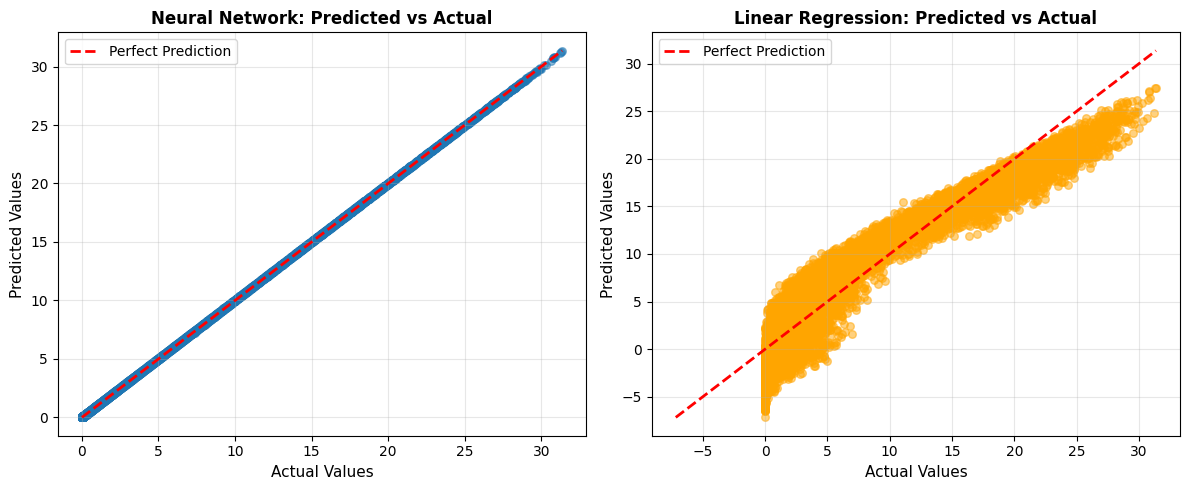

Neural Network R²: 1.0000
Linear Regression R²: 0.8972


In [24]:
# Get predictions from both models
nn_pred = options_nn_model(options_X_test_t).detach().numpy().flatten()
lr_pred = base_model.predict(options_X_test)

# Create scatter plot
plt.figure(figsize=(12, 5))

# Plot 1: Neural Network
plt.subplot(1, 2, 1)
plt.scatter(options_y_test, nn_pred, alpha=0.5, s=30)
plt.xlabel('Actual Values', fontsize=11)
plt.ylabel('Predicted Values', fontsize=11)
plt.title('Neural Network: Predicted vs Actual', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
# Add perfect prediction line
min_val = min(options_y_test.min(), nn_pred.min())
max_val = max(options_y_test.max(), nn_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.legend()

# Plot 2: Linear Regression
plt.subplot(1, 2, 2)
plt.scatter(options_y_test, lr_pred, alpha=0.5, s=30, color='orange')
plt.xlabel('Actual Values', fontsize=11)
plt.ylabel('Predicted Values', fontsize=11)
plt.title('Linear Regression: Predicted vs Actual', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
# Add perfect prediction line
min_val = min(options_y_test.min(), lr_pred.min())
max_val = max(options_y_test.max(), lr_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
plt.legend()

plt.tight_layout()
plt.show()

# Calculate R² for both models
from sklearn.metrics import r2_score
nn_r2 = r2_score(options_y_test, nn_pred)
lr_r2 = r2_score(options_y_test, lr_pred)

print(f"Neural Network R²: {nn_r2:.4f}")
print(f"Linear Regression R²: {lr_r2:.4f}")

Since the objective is to hug the 45 degree line as much as possible, we can see that the neural network is able to learn the function significantly easier than the linear regression.

c:\Users\micha\OneDrive\Documents1\homework\RSM338\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\micha\OneDrive\Documents1\homework\RSM338\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\micha\OneDrive\Documents1\homework\RSM338\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\micha\OneDrive\Documents1\homework\RSM338\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\micha\OneDrive\Documents1\homework\RSM338\.venv\Lib\site-packages\sklearn\utils\validat

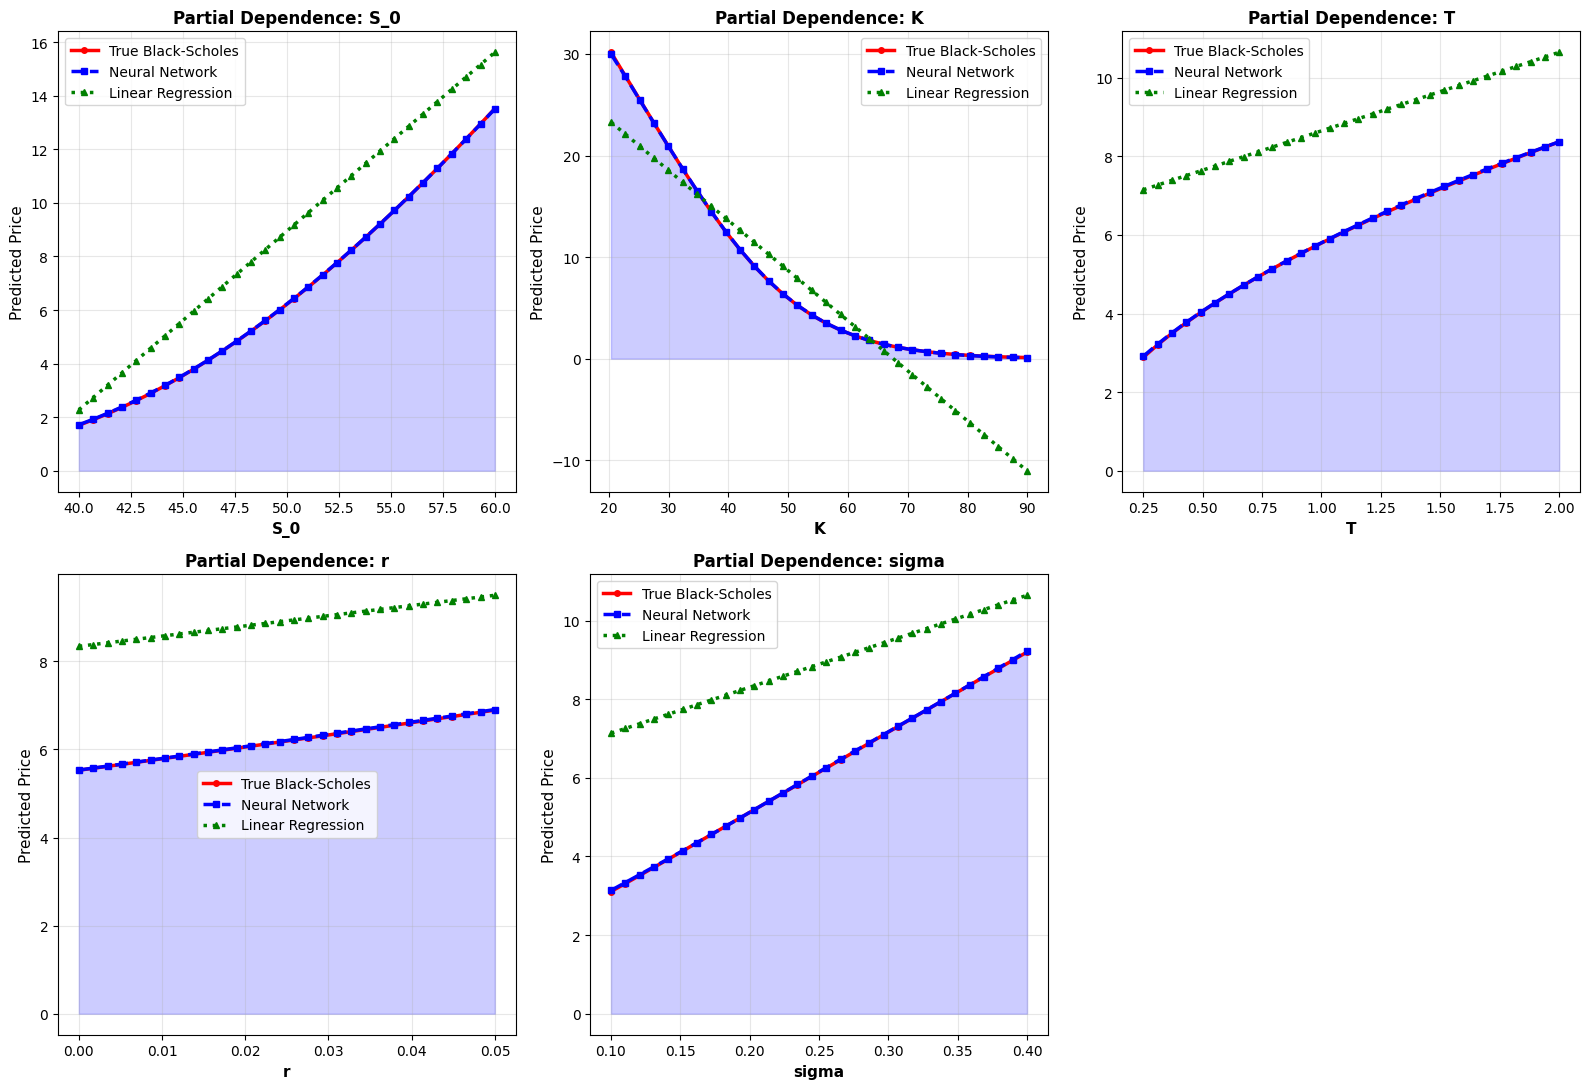

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def partial_dependence_with_true_values(model, X_unscaled, scaler, feature_index, num_points=30):
    """
    Compute partial dependence for a single feature.
    Holds all other features at their median values.
    Returns both NN predictions and true Black-Scholes prices.
    """
    # Create a baseline with median values for all features (unscaled)
    X_baseline = X_unscaled.median().values.reshape(1, -1)
    X_baseline = np.tile(X_baseline, (num_points, 1))
    
    feature_range = np.linspace(X_unscaled.iloc[:, feature_index].min(), 
                                X_unscaled.iloc[:, feature_index].max(), 
                                num_points)
    
    # Vary the target feature
    X_baseline[:, feature_index] = feature_range
    
    # Get NN predictions (need to scale the data)
    X_baseline_scaled = scaler.transform(X_baseline)
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_baseline_scaled.copy())
        nn_predictions = model(X_tensor).numpy().flatten()
    
    # Compute true Black-Scholes prices for comparison
    true_prices = []
    feature_names = X_unscaled.columns.tolist()
    
    for i in range(num_points):
        s = X_baseline[i, feature_names.index('S_0')]
        k = X_baseline[i, feature_names.index('K')]
        t = X_baseline[i, feature_names.index('T')]
        r = X_baseline[i, feature_names.index('r')]
        sigma = X_baseline[i, feature_names.index('sigma')]
        true_price = black_scholes(s, k, t, r, sigma)
        true_prices.append(true_price)
    
    return feature_range, nn_predictions, np.array(true_prices)

# Get feature names
feature_names = options_X.columns.tolist()

# Create partial dependence plots for all 5 features
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
axes = axes.flatten()

for i, feature_name in enumerate(feature_names):
    feature_range, nn_preds, true_prices = partial_dependence_with_true_values(
        options_nn_model, 
        options_X_test,
        scaler,
        i
    )
    
    # Get linear regression predictions
    X_baseline = options_X_test.median().values.reshape(1, -1)
    X_baseline = np.tile(X_baseline, (len(feature_range), 1))
    X_baseline[:, i] = feature_range
    lr_preds = base_model.predict(X_baseline)
    
    # Plot true Black-Scholes prices
    axes[i].plot(feature_range, true_prices, linewidth=2.5, color='red', label='True Black-Scholes', marker='o', markersize=4)
    
    # Plot NN predictions
    axes[i].plot(feature_range, nn_preds, linewidth=2.5, color='blue', label='Neural Network', linestyle='--', marker='s', markersize=4)
    
    # Plot LR predictions
    axes[i].plot(feature_range, lr_preds, linewidth=2.5, color='green', label='Linear Regression', linestyle=':', marker='^', markersize=4)
    
    # Fill between for NN predictions
    axes[i].fill_between(feature_range, nn_preds, alpha=0.2, color='blue')
    
    axes[i].set_xlabel(feature_name, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Predicted Price', fontsize=11)
    axes[i].set_title(f'Partial Dependence: {feature_name}', fontweight='bold', fontsize=12)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=10)

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

The neural network captures all the inputs well. The linear regression, as the name suggests, fails spectacularly at capturing non-linear relationships.

The current neural network model technically outputs R^2 = 1 (this may just be a rounding error). However, this may be insufficient for real options traders since the Black-Scholes formula is not the be all and end all to options pricing. A related approach would be running a neural network over the same five inputs but against real option prices, which can be more realistic at the cost of noise.

**Appendix**
Claude Code was used for writing the code in this assignment. Google AI was also briefly used due to its automatic results when searching things up on Google.